# Name: PUjan Upadhyay
# Group: 16
# College ID: np03cs4a230284
# Worksheet: 5

In [90]:
#drive connection
#from google.colab import drive
#drive.mount('/content/drive')

In [91]:
#zip dataset path
#zip_path = '/content/drive/MyDrive/AI ML/week5/Copy of FruitinAmazon.zip'

In [92]:
#unzip the dataset file
#import zipfile
#import os
#
#extract_path = '/content/drive/MyDrive/AI ML/week5'
#
#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#    zip_ref.extractall(extract_path)
#
#print("Unzipped successfully!")

**Implementation of an End-to-End CNN Model for Image Classification Task**

# Data Understanding and Visualization
Load and visualize the images data

In [93]:
#imports
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [94]:
#train dataset path
train_dir = "/content/drive/MyDrive/AI ML/week5/FruitinAmazon/train"

#list of each directories inside train directory
classes = os.listdir(train_dir)
print("Classes:", classes)

Classes: ['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']


In [95]:
images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    images.append((cls, img_path))

=> Selects one random image from each class(sub directory). It loops through each class and build full path to class folder then gets all the images and then select one randomly and store it in the images as class name and image path.

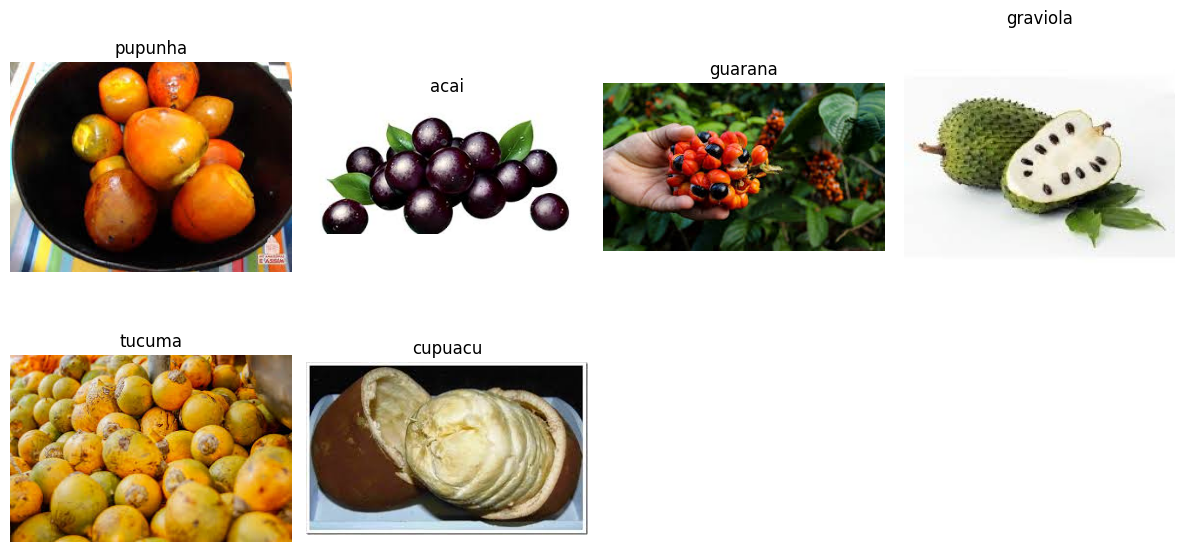

In [96]:
plt.figure(figsize=(12, 6))

for i, (cls, img_path) in enumerate(images):
    plt.subplot(2, len(images)//2 + 1, i+1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

=> This displays the selected image from above code in a grid style. It loops through the index of images and display it with the title as class name. For this it create a grid of 2 rows and keep the figure size to (12,6) and show the image.

In [97]:
#Check for Corrupted Image
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


=> This code Detects and remove the broken images. It does this by using try-except situation. First the Image.open() is used to read the image and then that image is verified by img.verify(). if that image is correpted then will through the error and it is catched by excepted and then that path is added to corrupted and then that image is removed. It does this for all the images then at end will check for corrupted_images and if its count is equals to 0 then will print No corrupted images found.

# Loading and Preprocessing Image Data in Keras

In [98]:
#impot and setting vlaue for image data
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

In [99]:
#convert the pixel value to either 0 or 1.
rescale = tf.keras.layers.Rescaling(1./255)

In [100]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [101]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


=> In the above code for train_ds and val_ds the train dataset was split into 80% train and 20% for validation with each dataset with their properties

# CNN Model

In [102]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

=>This is the CNN architecture, which is designed to automatically extract features from images and classify them into different categories. The model is built using a sequential structure where layers are added one after another. The first convolutional layer applies 32 filters of size 3×3 to the input image, allowing the network to detect low-level features such as edges and textures. The padding='same' ensures that the spatial dimensions of the image are preserved, while the ReLU activation introduces non-linearity, enabling the model to learn complex patterns. This is followed by a max pooling layer, which reduces the spatial dimensions by selecting the most important features, thereby reducing computational complexity and preventing overfitting. A second convolutional layer further refines feature extraction by identifying higher-level patterns such as shapes and object parts, followed again by pooling. The flatten layer then converts the multi-dimensional feature maps into a one-dimensional vector, making it compatible with fully connected layers. The dense layers (with 64 and 128 neurons) learn complex combinations of features and act as the decision-making part of the network. Finally, the output layer uses a softmax activation function to produce probability distributions over all classes, allowing the model to make a final classification.

In [103]:
#Compile Module
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

=> this prepares the model for training with components to update weights effciently, measures error and performace metric.

In [104]:
#Train the model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.1701 - loss: 2.1479

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 865ms/step - accuracy: 0.1667 - loss: 2.2939 - val_accuracy: 0.8333 - val_loss: 1.4429
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.1667 - loss: 1.8325 - val_accuracy: 0.0000e+00 - val_loss: 1.8562
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.3056 - loss: 1.6566 - val_accuracy: 0.3333 - val_loss: 1.6772
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.4306 - loss: 1.5499 - val_accuracy: 0.1111 - val_loss: 1.6613
Epoch 5/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.2109 - loss: 1.4417 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.2639 - loss: 1.4364 - val_accuracy: 0.6667 - val_loss: 1.2658
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5920 - loss: 1.2605

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5417 - loss: 1.2539 - val_accuracy: 0.5556 - val_loss: 1.1766
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5833 - loss: 1.0528 - val_accuracy: 0.5000 - val_loss: 1.3835
Epoch 8/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7188 - loss: 0.9635 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7361 - loss: 0.8825 - val_accuracy: 0.8333 - val_loss: 0.8967
Epoch 9/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8750 - loss: 0.6220 

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.9028 - loss: 0.3420 - val_accuracy: 0.6667 - val_loss: 0.6856
Epoch 12/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8828 - loss: 0.2903

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.9028 - loss: 0.2712 - val_accuracy: 0.8889 - val_loss: 0.5851
Epoch 13/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9688 - loss: 0.1642

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.9722 - loss: 0.1506 - val_accuracy: 0.8333 - val_loss: 0.4678
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9722 - loss: 0.1333 - val_accuracy: 0.8333 - val_loss: 0.5253
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 1.0000 - loss: 0.0640 - val_accuracy: 0.8889 - val_loss: 0.6795
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9861 - loss: 0.0528 - val_accuracy: 0.7778 - val_loss: 0.5751
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 1.0000 - loss: 0.0231 - val_accuracy: 0.8333 - val_loss: 0.5205
Epoch 18/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.0203 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 1.0000 - loss: 0.0212 - val_accuracy: 0.8333 - val_loss: 0.3867
Epoch 19/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 1.0000 - loss: 0.0075 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 0.8889 - val_loss: 0.3862
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.8889 - val_loss: 0.4401
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 0.8889 - val_loss: 0.4772
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.8333 - val_loss: 0.5579
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.8333 - val_loss: 0.5323
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8333 - val_loss: 0.4789
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8333 - val_loss: 0.4581
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8333 - val_loss

=> This code trains the model. Here the number of training cycles is defined the it checls the performace on the unseen data which was seperated as 20% from the taining data. Then it prevents and save the best model using callbacks.

In [105]:
#Evaluate the Model
test_loss, test_acc = model.evaluate(val_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8889 - loss: 0.3862
Test Loss: 0.38621169328689575
Test Accuracy: 0.8888888955116272


=> This tests model on unseen data which is the seperated 20% data.

In [106]:
#Save the Model
model.save("week5_cnn_model.h5")

=> This saves the model so it can be used again without being to run the whole model train process and saving time.

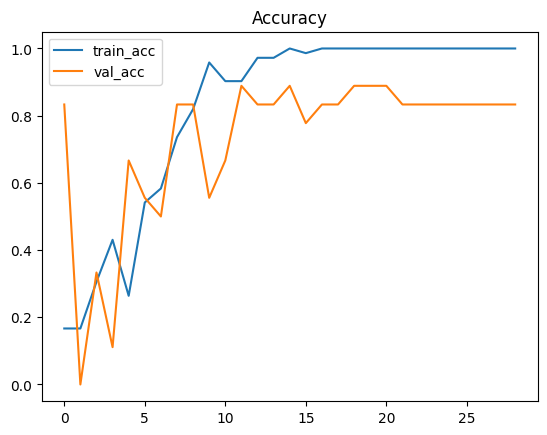

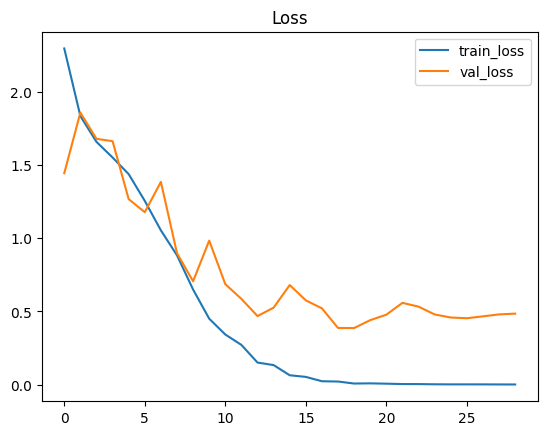

In [107]:
#Visualization of taining and validation loss and accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

The graph shows how well the model was learning over time during training. There are two lines one for training loss (blue) and one for validation loss (orange). Both start high, around 1.8, which means the model was making a lot of mistakes at the beginning because it had not seen any data yet.
As training continued, the blue line (train loss) dropped very smoothly and steadily all the way down close to zero. This means the model got really good at recognizing the fruits it was trained on. However, the orange line (validation loss) behaved very differently it kept jumping up and down, going high and low randomly between epochs 7 to 13. This shaky behavior tells us the model was overfitting, meaning it memorized the training images instead of truly learning to recognize fruits in general. The main reason the validation line is so unstable is that there were only 18 images in the validation set, so even one wrong prediction caused a big jump in the graph.

# Predictions and Classification Report

In [108]:
#Test Data
test_dir = "/content/drive/MyDrive/AI ML/week5/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

#normalization
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [109]:
#loss and accuracy on test data
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.6667 - loss: 0.9937
Test Loss: 0.9937
Test Accuracy: 0.6667


In [110]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


In [111]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

     pupunha       0.71      1.00      0.83         5
        acai       0.83      1.00      0.91         5
     guarana       0.83      1.00      0.91         5
    graviola       0.67      0.40      0.50         5
      tucuma       0.50      0.20      0.29         5
     cupuacu       0.33      0.40      0.36         5

    accuracy                           0.67        30
   macro avg       0.65      0.67      0.63        30
weighted avg       0.65      0.67      0.63        30



The report has three main columns to understand. Precision tells you how often the model was right when it pointed at a fruit. Recall tells you how many of the actual fruits the model managed to find. F1-score is just a combined average of both, giving you one simple number to judge overall performance per class.
Looking at the results, graviola was the easiest fruit for the model it got everything right with a perfect score of 1.00 across all three metrics. Pupunha and tucuma also performed well, with F1 scores of 0.91 and 0.89 respectively. Guarana had perfect recall meaning the model never missed a guarana, but it was also calling other fruits guarana by mistake, which pulled its precision down to 0.62. Acai was moderate at 0.67. The worst performing class was cupuacu with only a 0.50 F1-score, meaning the model got confused half the time with this fruit, likely because it looks visually similar to the others.
Overall the model achieved 80% accuracy on the test set, correctly identifying 24 out of 30 images.